<a href="https://colab.research.google.com/github/NinhHTK/ML-CPV-Documents/blob/main/SE196288_Transfer_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Image Classification: Horse or Human

In [ ]:
import tensorflow as tf
import zipfile
import os

# Download the training dataset
!wget -q https://storage.googleapis.com/tensorflow-1-public/course2/week3/horse-or-human.zip -O /tmp/horse-or-human.zip

# Download the validation dataset
!wget -q https://storage.googleapis.com/tensorflow-1-public/course2/week3/validation-horse-or-human.zip -O /tmp/validation-horse-or-human.zip

# Extract the training dataset
with zipfile.ZipFile('/tmp/horse-or-human.zip', 'r') as zip_ref:
    zip_ref.extractall('/tmp/horse-or-human')

# Extract the validation dataset
with zipfile.ZipFile('/tmp/validation-horse-or-human.zip', 'r') as zip_ref:
    zip_ref.extractall('/tmp/validation-horse-or-human')

print("Datasets downloaded and extracted successfully.")

Datasets downloaded and extracted successfully.


In [ ]:
# Define directories for training and validation data
train_dir = '/tmp/horse-or-human'
validation_dir = '/tmp/validation-horse-or-human'

# Check the number of images in each subdirectory
train_horses_dir = os.path.join(train_dir, 'horses')
train_humans_dir = os.path.join(train_dir, 'humans')
validation_horses_dir = os.path.join(validation_dir, 'horses')
validation_humans_dir = os.path.join(validation_dir, 'humans')

print(f"Total training horse images: {len(os.listdir(train_horses_dir))}")
print(f"Total training human images: {len(os.listdir(train_humans_dir))}")
print(f"Total validation horse images: {len(os.listdir(validation_horses_dir))}")
print(f"Total validation human images: {len(os.listdir(validation_humans_dir))}")

Total training horse images: 500
Total training human images: 527
Total validation horse images: 128
Total validation human images: 128


Next, I will set up the `ImageDataGenerator` for data augmentation and preprocessing, and then prepare the image data generators for training and validation.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# All images will be re-scaled by 1./255
train_datagen = ImageDataGenerator(rescale=1/255,
                                   rotation_range=40,
                                   width_shift_range=0.2,
                                   height_shift_range=0.2,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True,
                                   fill_mode='nearest')

validation_datagen = ImageDataGenerator(rescale=1/255)

# Flow training images in batches of 128 using train_datagen generator
train_generator = train_datagen.flow_from_directory(
        train_dir,  # This is the source directory for training images
        target_size=(300, 300),  # All images will be resized to 300x300
        batch_size=128,
        class_mode='binary') # Since we use binary_crossentropy loss, we need binary labels

# Flow validation images in batches of 128 using validation_datagen generator
validation_generator = validation_datagen.flow_from_directory(
        validation_dir,  # This is the source directory for validation images
        target_size=(300, 300),  # All images will be resized to 300x300
        batch_size=32,
        class_mode='binary')  # Since we use binary_crossentropy loss, we need binary labels

print("ImageDataGenerators and data flows set up successfully.")

Found 1027 images belonging to 2 classes.
Found 256 images belonging to 2 classes.
ImageDataGenerators and data flows set up successfully.


Next, I will build a Convolutional Neural Network (CNN) model using a pre-trained base model (InceptionV3) and add custom classification layers on top.

In [ ]:
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.optimizers import RMSprop

# Load the InceptionV3 model, pre-trained on ImageNet
# Exclude the top (classification) layers
pre_trained_model = InceptionV3(input_shape=(300, 300, 3),
                                  include_top=False,
                                  weights='imagenet')

# Freeze the layers of the pre-trained model
for layer in pre_trained_model.layers:
    layer.trainable = False

# Add custom classification layers
last_output = pre_trained_model.output
x = tf.keras.layers.Flatten()(last_output)
x = tf.keras.layers.Dense(1024, activation='relu')(x)
x = tf.keras.layers.Dropout(0.2)(x)
x = tf.keras.layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(pre_trained_model.input, x)

# Compile the model
model.compile(optimizer=RMSprop(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()
print("Model defined and compiled successfully.")

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_94 (Conv2D)  │ (None, 149, 149,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 149, 149,  │         96 │ conv2d_94[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_94       │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_95 (Conv2D)  │ (None, 147, 147,  │      9,216 │ activation_94[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │         96 │ conv2d_95[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_95       │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_96 (Conv2D)  │ (None, 147, 147,  │     18,432 │ activation_95[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        192 │ conv2d_96[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_96       │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 73, 73,    │          0 │ activation_96[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_97 (Conv2D)  │ (None, 73, 73,    │      5,120 │ max_pooling2d_4[… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        240 │ conv2d_97[0][0]   │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_97       │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_98 (Conv2D)  │ (None, 71, 71,    │    138,240 │ activation_97[0]… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        576 │ conv2d_98[0][0]   │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_98       │ (None, 71, 71,    │          0 │ batch_normalizat

 Total params: 156,022,561 (595.18 MB)

 Trainable params: 134,219,777 (512.01 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

Model defined and compiled successfully.


With the model defined, the next step is to train it using the `ImageDataGenerator`s we set up earlier.

In [16]:
import math

history = model.fit(
    train_generator,
    steps_per_epoch=math.ceil(train_generator.samples / train_generator.batch_size),
    epochs=10,
    validation_data=validation_generator,
    validation_steps=math.ceil(validation_generator.samples / validation_generator.batch_size),
    verbose=1
)

Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 427s 47s/step - accuracy: 0.9912 - loss: 0.0555 - val_accuracy: 1.0000 - val_loss: 4.9452e-06
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 412s 46s/step - accuracy: 0.9961 - loss: 0.0157 - val_accuracy: 1.0000 - val_loss: 9.7085e-06
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 423s 47s/step - accuracy: 0.9961 - loss: 0.0183 - val_accuracy: 1.0000 - val_loss: 2.3560e-06
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 430s 53s/step - accuracy: 0.9990 - loss: 0.0052 - val_accuracy: 1.0000 - val_loss: 2.4322e-08
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 430s 46s/step - accuracy: 1.0000 - loss: 1.1626e-04 - val_accuracy: 1.0000 - val_loss: 3.7622e-08
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 429s 47s/step - accuracy: 0.9990 - loss: 0.0076 - val_accuracy: 1.0000 - val_loss: 3.2523e-05
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 438s 47s/step - accuracy: 0.9854 - loss: 0.0755 - val_accuracy: 1.0000 - val_loss: 5.0929e-10
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 439s 48s/step - accuracy: 1.0000 - loss: 2.2781e-0

After training, I will plot the training and validation accuracy and loss to evaluate the model's performance.

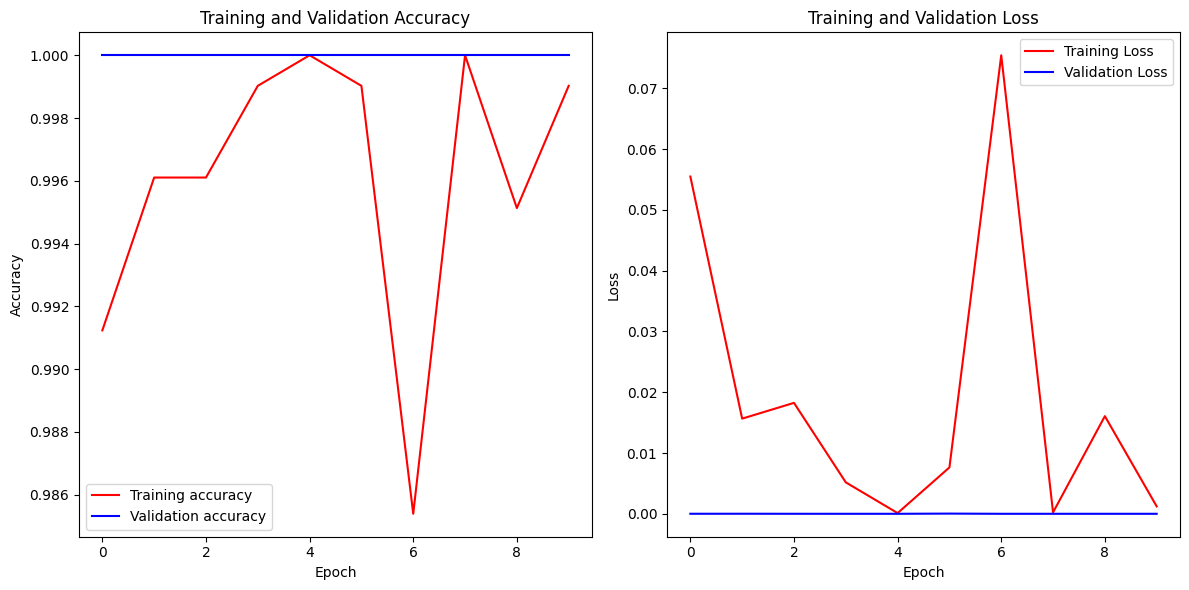

In [18]:
import matplotlib.pyplot as plt

# Retrieve a list of list results on training and validation data sets for each training epoch
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.figure(figsize=(12, 6))

# Plot training and validation accuracy per epoch
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc=0)

# Plot training and validation loss per epoch
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'r', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc=0)

plt.tight_layout()
plt.show()